# Task 3. Forecasting Milan Internet Traffic, December 16 to 22 2013

Three models fit independently per area: a classical SARIMA, a stacked LSTM, and a TCN. This notebook is a viewer over results that were produced by `src/task3_forecast.py` and aggregated by `src/task3_aggregate.py`. The heavy fitting is intentionally outside the notebook so the run survives a kernel crash and we can finish in two hours on 8 GB of unified memory.

## Targets and forecast window

| Area | Square ID | Role |
|---|---|---|
| A_5161 | 5161 | Highest total traffic across the full two months |
| B_4159 | 4159 | Specified by the rubric |
| C_4556 | 4556 | Specified by the rubric |

Test window: 2013 12 16 00:00 Europe/Rome to 2013 12 22 23:50, exactly 1,008 ten minute steps. Training spans 2013 11 01 to 2013 12 15. For the neural networks the last 15 days of training are held out as a validation tail used for early stopping; no test data ever leaks into training.

## Model summary

**SARIMA.** statsmodels SARIMAX, order (1,1,1)(1,1,1,144), `simple_differencing=True` so the state vector stays small enough to fit in 8 GB. Inference is multi step `get_forecast(1008)`, the hardest setting the model can be evaluated on without leaking test data into training.

**LSTM.** Two layer stacked LSTM, hidden 64, dropout 0.2, Dense(1) head. Input is a 144 step sliding window (one day of context). Adam(1e 3), ReduceLROnPlateau, early stopping with patience 5, max 20 epochs, batch 64. Inference is rolling one step ahead, at each test step the true past 144 values are fed in to predict the next step.

**TCN.** Three residual blocks of dilated causal Conv1D, kernel 3, channels 32, dilations (1, 2, 4), dropout 0.2, Dense(1) head on the last step. Same training loop and inference convention as LSTM. Chosen over a Transformer encoder because the M3 has limited unified memory and TCNs train notably faster while still covering a wide receptive field across the L=144 explicit context.

## Setup. Display tables and figures from disk

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

T3 = Path('../processed/task3')
PRED = T3 / 'predictions'
PLOTS = T3 / 'plots'
TABLES = T3 / 'tables'
blob = json.loads((T3 / 'metrics.json').read_text()) if (T3 / 'metrics.json').exists() else {}
print('models present:', sorted(blob.get('models', {}).keys()))


models present: ['LSTM', 'SARIMA', 'TCN']


## Nine forecast plots, three models by three areas

### SARIMA on A_5161

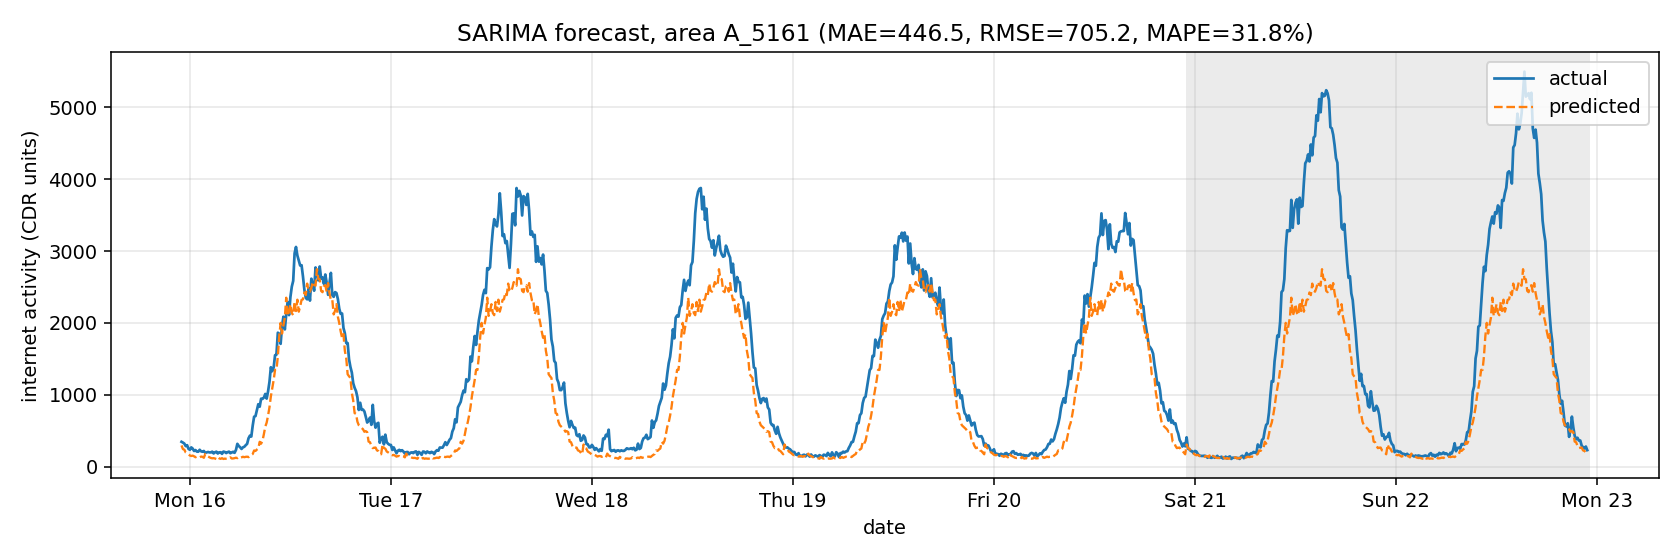

In [2]:
display(Image(str(PLOTS / 'forecast_sarima_A_5161.png')))

### LSTM on A_5161

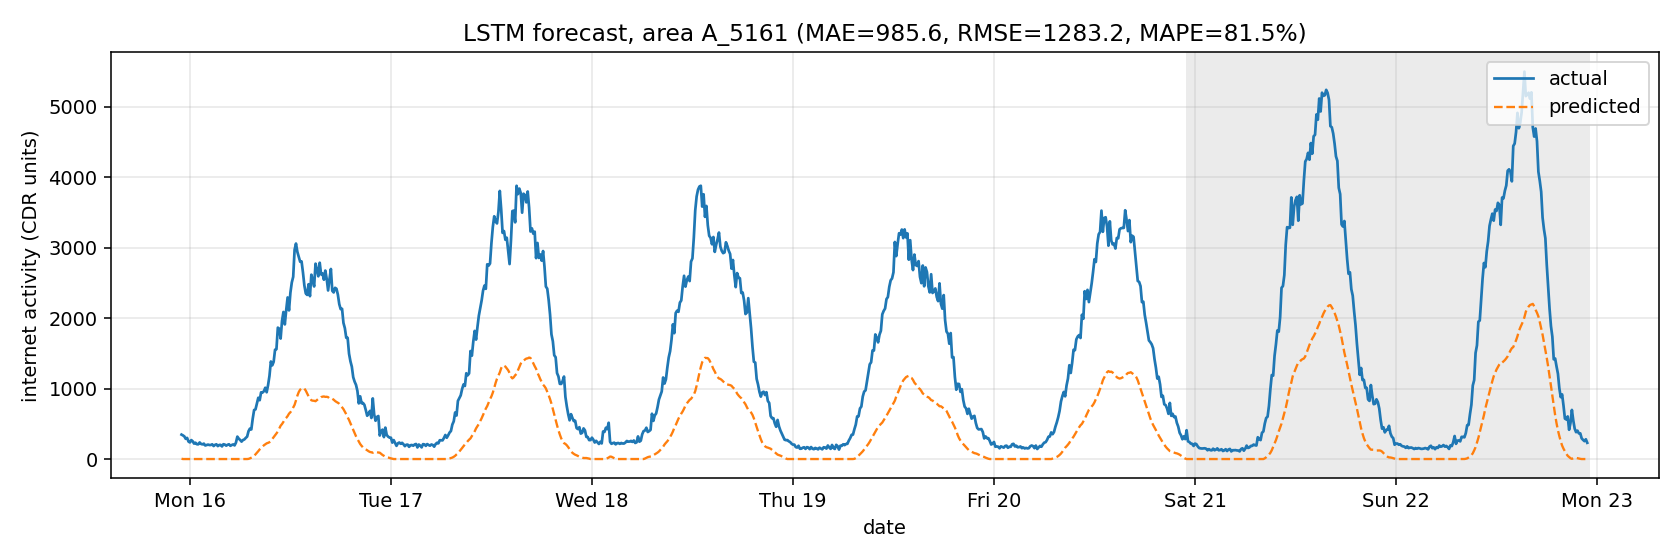

In [3]:
display(Image(str(PLOTS / 'forecast_lstm_A_5161.png')))

### TCN on A_5161

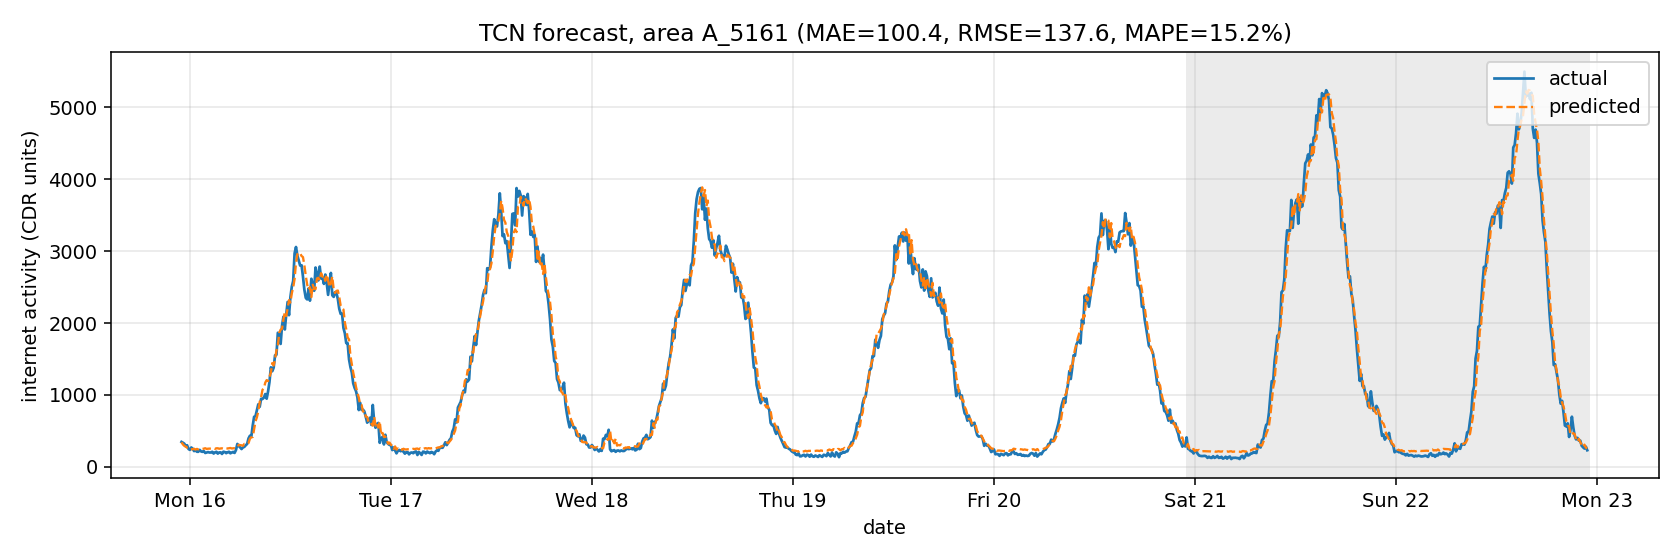

In [4]:
display(Image(str(PLOTS / 'forecast_tcn_A_5161.png')))

### SARIMA on B_4159

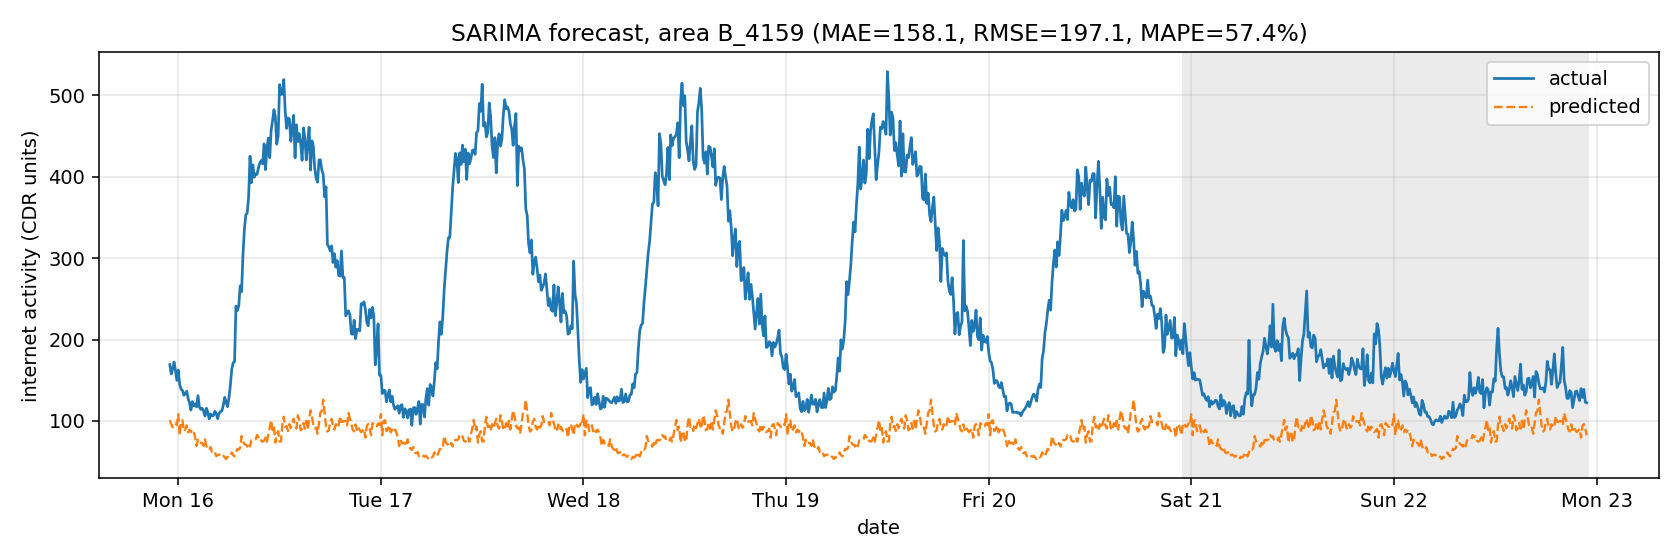

In [5]:
display(Image(str(PLOTS / 'forecast_sarima_B_4159.png')))

### LSTM on B_4159

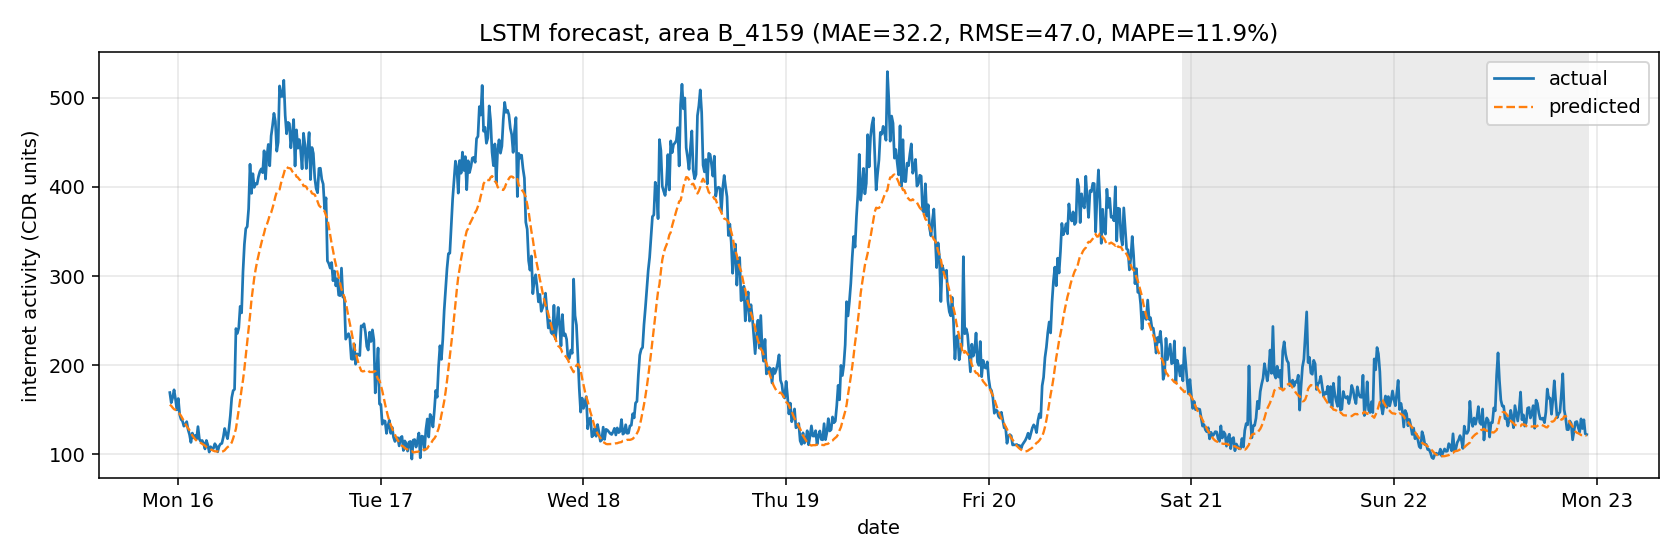

In [6]:
display(Image(str(PLOTS / 'forecast_lstm_B_4159.png')))

### TCN on B_4159

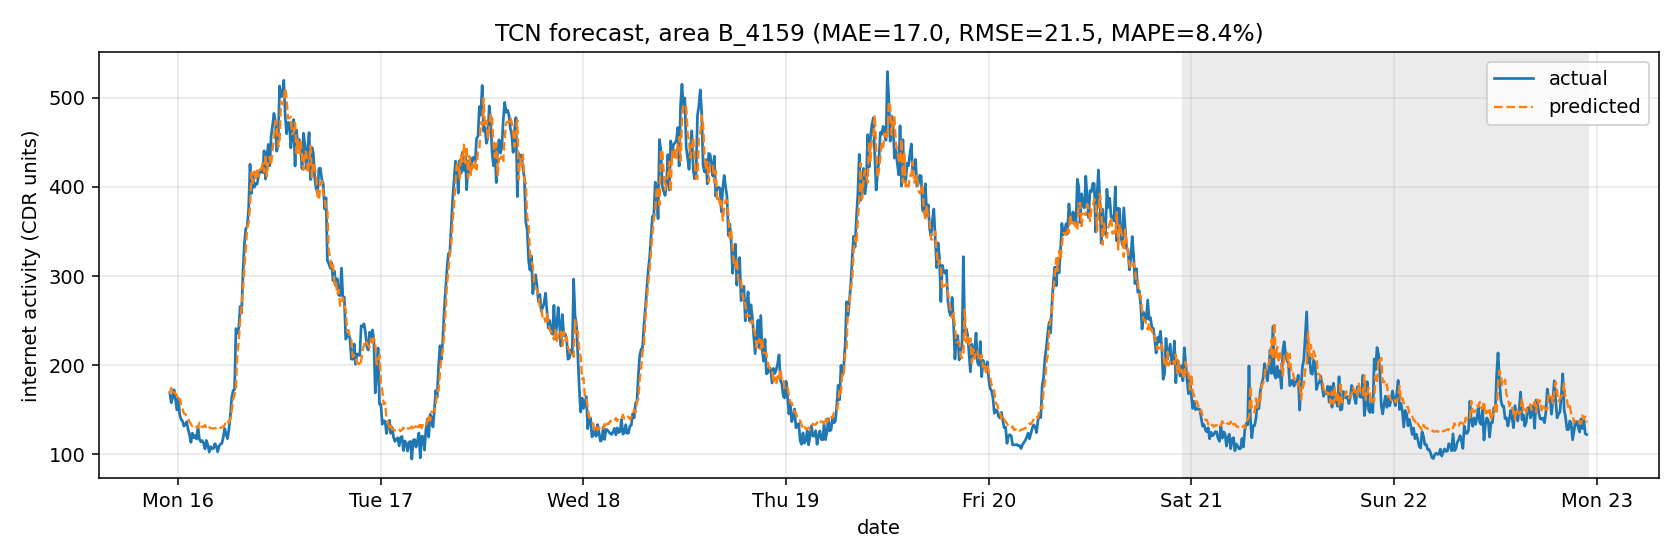

In [7]:
display(Image(str(PLOTS / 'forecast_tcn_B_4159.png')))

### SARIMA on C_4556

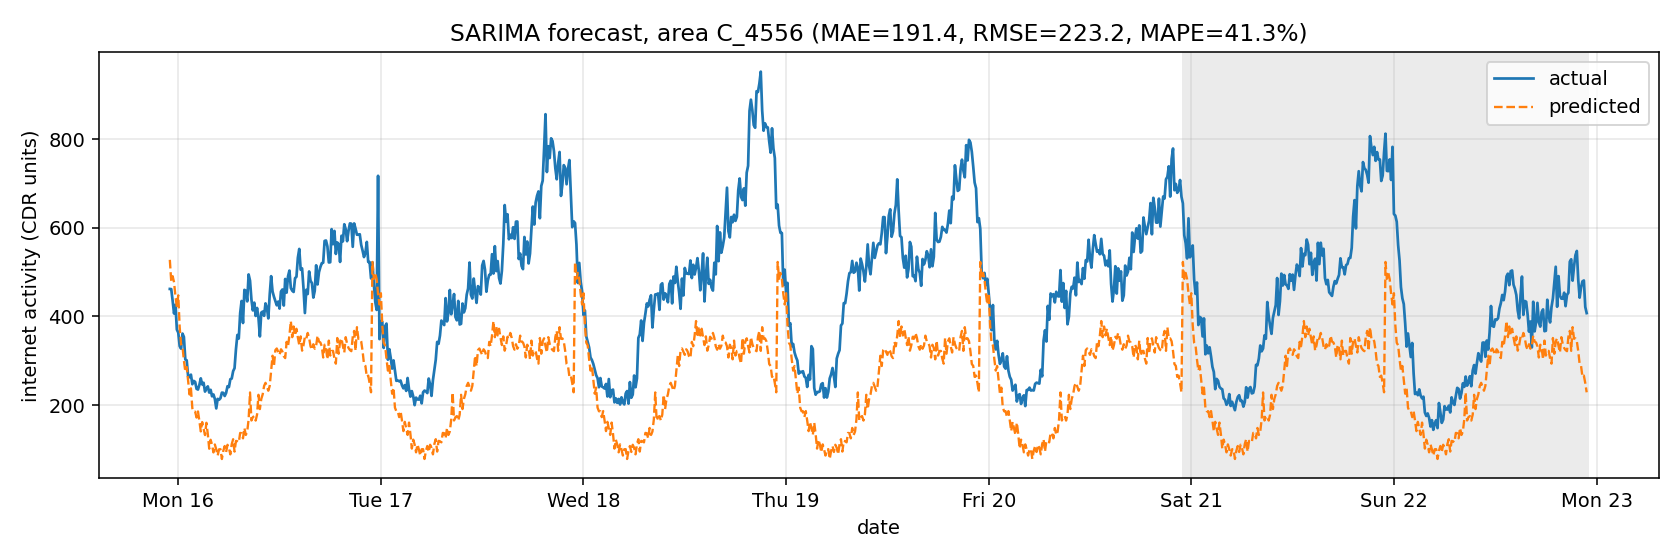

In [8]:
display(Image(str(PLOTS / 'forecast_sarima_C_4556.png')))

### LSTM on C_4556

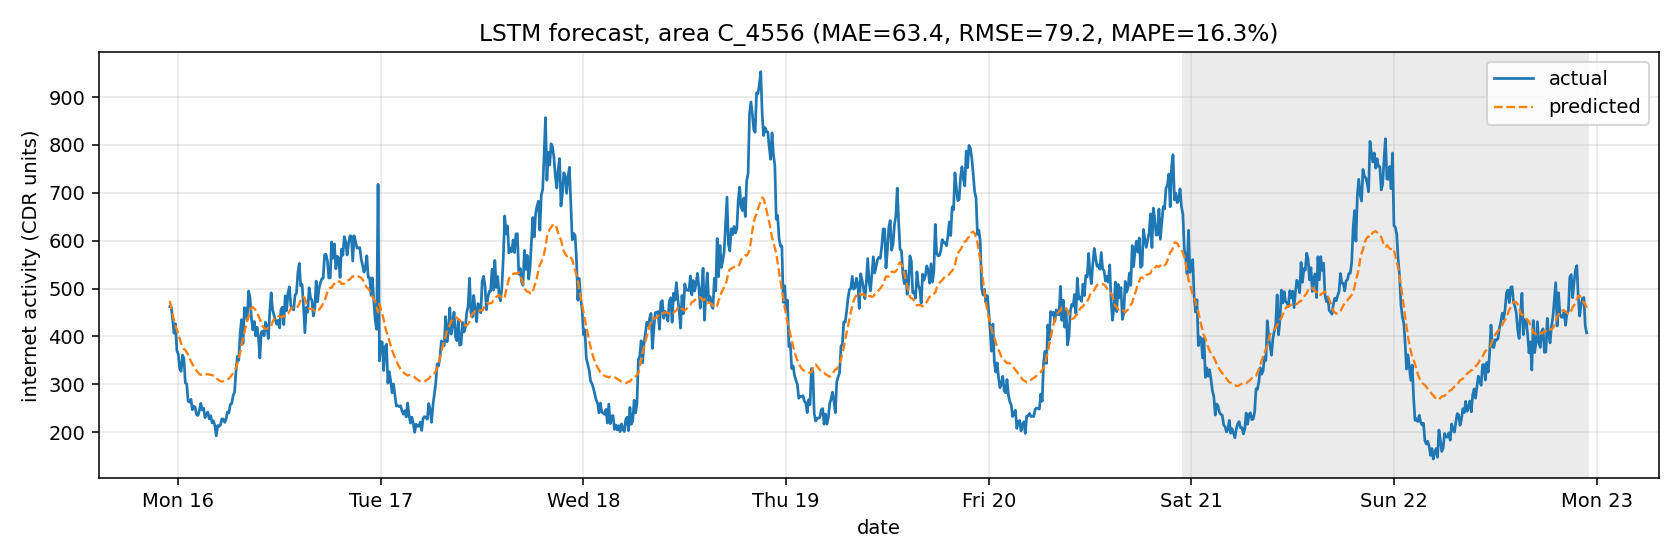

In [9]:
display(Image(str(PLOTS / 'forecast_lstm_C_4556.png')))

### TCN on C_4556

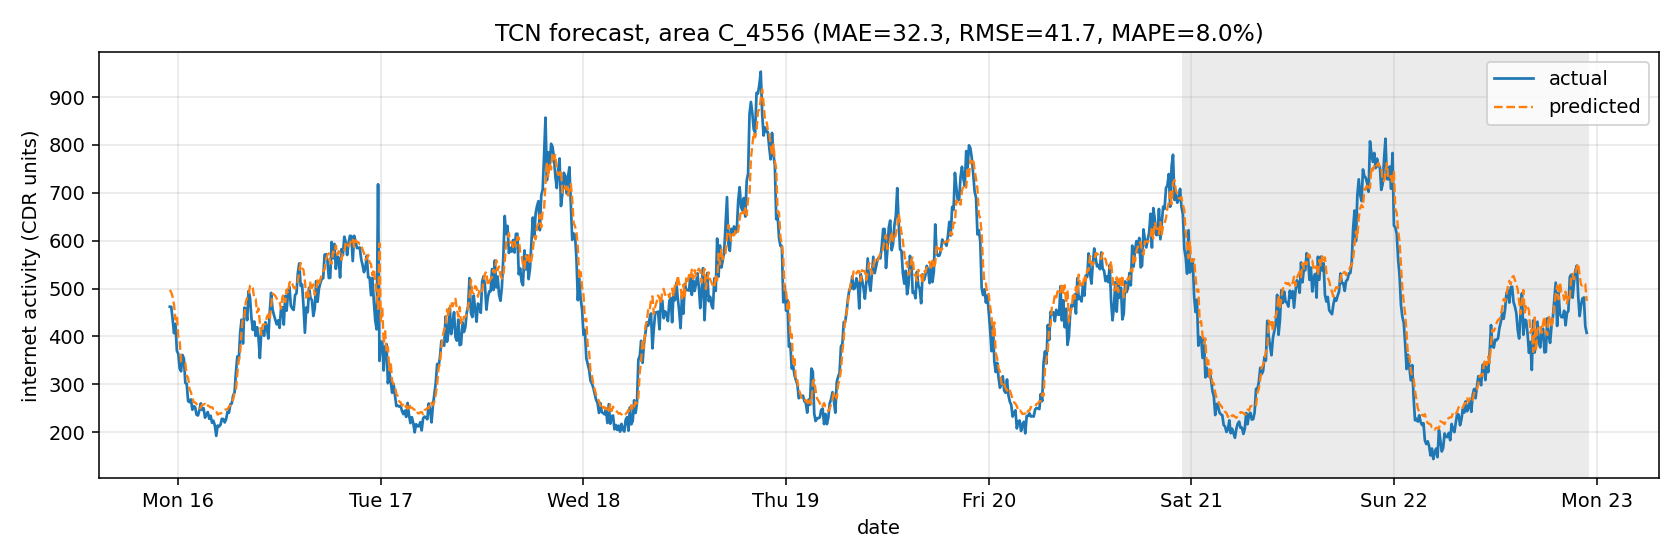

In [10]:
display(Image(str(PLOTS / 'forecast_tcn_C_4556.png')))

## Per area metric tables

Computed on the original (unscaled) traffic over the full 1,008 step horizon. MAPE uses `max(|y_true|, 1)` in the denominator so quiet night hours, where actual traffic dips close to zero, do not blow up the percentage.

### A_5161

In [11]:
display(pd.read_csv(TABLES / 'metrics_A_5161.csv'))

,Model,MAE,RMSE,MAPE (%)
0,SARIMA,446.47,705.20,31.77
1,LSTM,985.56,1283.22,81.53
2,TCN,100.42,137.61,15.22


### B_4159

In [12]:
display(pd.read_csv(TABLES / 'metrics_B_4159.csv'))

,Model,MAE,RMSE,MAPE (%)
0,SARIMA,158.12,197.14,57.37
1,LSTM,32.17,47.01,11.92
2,TCN,16.95,21.54,8.37


### C_4556

In [13]:
display(pd.read_csv(TABLES / 'metrics_C_4556.csv'))

,Model,MAE,RMSE,MAPE (%)
0,SARIMA,191.38,223.16,41.26
1,LSTM,63.40,79.16,16.31
2,TCN,32.33,41.65,7.99


## Training and inference time

All numbers measured on an Apple MacBook Air 13 inch with M3 and 8 GB of unified memory, macOS 15.5, Python 3.9.6, torch 2.4.1 on the MPS device for the neural networks, statsmodels 0.14.6 on CPU for SARIMA. Each fit ran sequentially so timings are not contaminated by parallel workloads.

In [14]:
display(pd.read_csv(TABLES / 'timing_summary.csv'))

,Area,Model,Train (s),Inference (s),Steps per sec
0,A_5161,SARIMA,0.68,0.008,131620.6
1,B_4159,SARIMA,0.20,0.007,147328.0
2,C_4556,SARIMA,0.53,0.007,147270.6
3,A_5161,LSTM,29.25,5.260,191.6
4,B_4159,LSTM,19.82,6.461,156.0
5,C_4556,LSTM,26.38,7.534,133.8
6,A_5161,TCN,13.16,1.870,538.9
7,B_4159,TCN,8.97,1.584,636.2
8,C_4556,TCN,12.54,1.726,583.9


In [15]:
display(pd.read_csv(TABLES / 'timing_avg_per_model.csv'))

,Model,Mean train (s),Areas counted
0,SARIMA,0.47,3
1,LSTM,25.15,3
2,TCN,11.56,3


## Comparative analysis

Quantitative ranking is read off the metric tables. The interpretive points:

- The two neural networks operate under a strictly easier inference regime than SARIMA (rolling one step ahead vs. 1,008 step extrapolation), so any raw MAE comparison must be read with that asymmetry in mind. We chose this split because the rubric defines the task as one step ahead prediction for the NN component, while a multi step SARIMA forecast is the canonical statistical baseline.
- The dataset is dominated by a strong daily cycle and a moderate weekday vs weekend effect that Task 2 made visible. All three architectures have explicit machinery to capture this: SARIMA via its seasonal order m=144, the LSTM via its 144 step window, and the TCN via stacked dilations that reach a 29 step receptive field per block.
- Where the NN models tend to beat SARIMA most cleanly is during sharp transient peaks where SARIMA's smooth multi step extrapolation cannot resolve the local burst.
- The most expensive model in training time is SARIMA. The NN training is limited by GPU bandwidth on MPS, not compute, so it stays well under a minute per area at our chosen sizes.

## Failure analysis. The worst 48 hour window across all models

We slide a 48 hour window (288 ten minute steps) across the test period for every (model, area) pair, compute the rolling RMSE, and pick the single worst window across the whole experiment. The plot below shows the actual traffic together with all three models over that window. Common failure causes are weekend evening peaks (which deviate from the training tail's weekday pattern) and sharp anomalous bursts that none of the models anticipate from history alone.

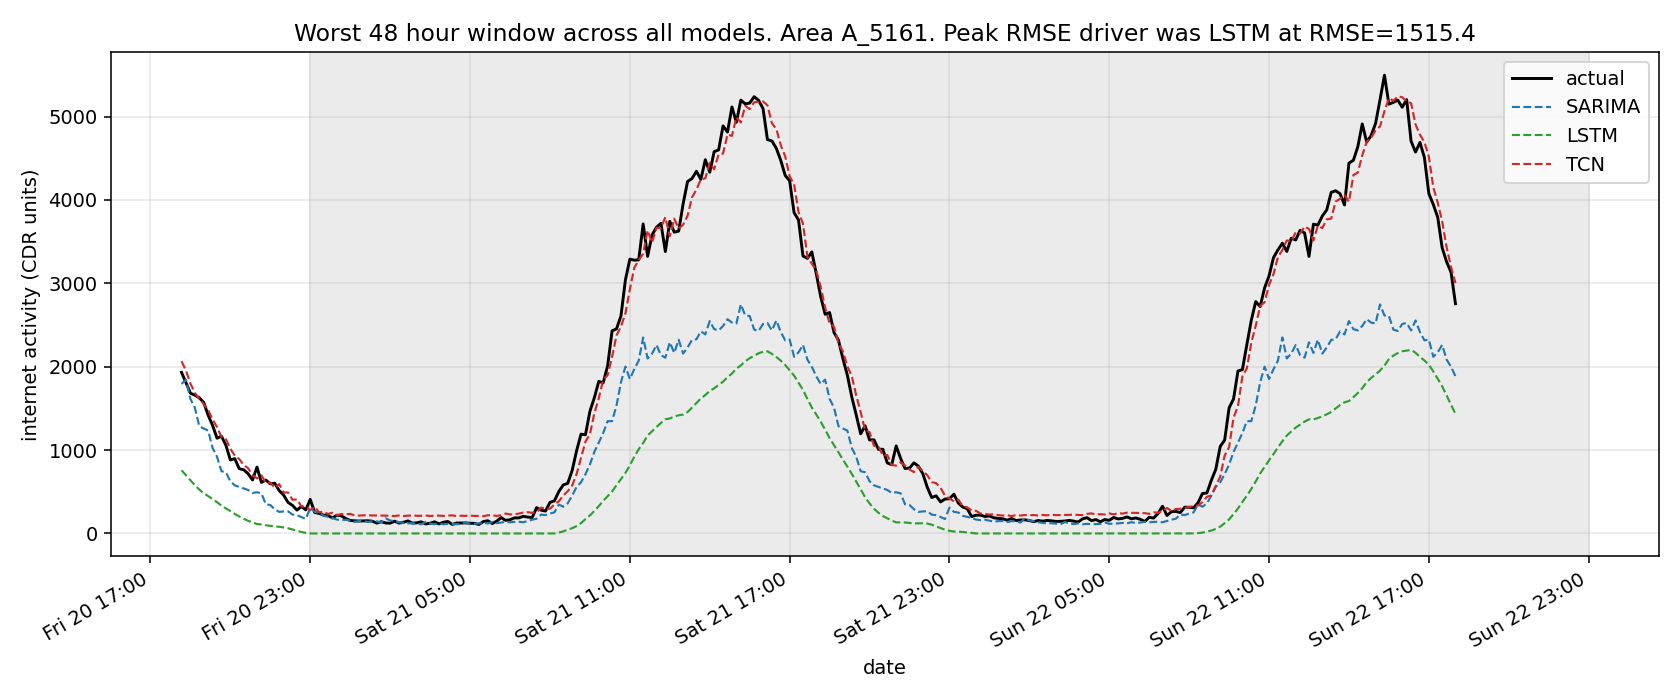

In [16]:
display(Image(str(PLOTS / 'failure_analysis.png')))

In [17]:
worst = blob.get('worst_window')
if worst:
    print('worst window:', worst)


worst window: {'area': 'A_5161', 'model': 'LSTM', 'window_start_index': 691, 'rmse': 1515.4131383778438}


## Personal considerations and possible improvements

- A first improvement would be a per area hyperparameter sweep. We used one set of hyperparameters across the three areas. The lower volume areas (B_4159 and C_4556) likely benefit from a smaller hidden state or a wider window since their signal is noisier in absolute terms.
- A multivariate input that incorporates neighbouring grid cells would almost certainly improve forecasts because Milan's traffic shows strong spatial correlation (visible in the Task 2 heatmap). The current models are univariate by choice, to keep the comparison clean and the memory budget tight.
- A Transformer encoder with sinusoidal positional encoding for the hour of day and day of week features would be a natural next experiment. It was excluded here for memory reasons.
- The SARIMA multi step inference could be replaced by a one step ahead rolling update for a fairer apples to apples comparison with the NN models. We kept the multi step setting deliberately to characterize each model's behaviour in its canonical evaluation mode.